# 06 — RSN Interpretability: Comparing Saliency, Integrated Gradients, Shapley, and LIME

For the chosen model (Experiment 4: multi-task Transformer), this notebook:

1. Stores a **per-window prediction** (not just epoch-aggregate metrics) for every test-set window — the decoded state at each timepoint.
2. Runs four interpretability methods on each window to infer **which resting-state network (RSN)** drove that decode: Saliency and Integrated Gradients (gradient-based, via Captum) and exact Shapley values and LIME (perturbation-based, over a 7-network coalition space).
3. Compares the four methods' agreement.
4. Demonstrates the full downstream step: decoded state + top RSN → a templated text query, per [docs/decoded-state-to-text-report.md](../docs/decoded-state-to-text-report.md) Levels 0-1.

See [docs/interpretability-methods-notes.md](../docs/interpretability-methods-notes.md) for why these four methods, why network-level pooling, and a survey of methods not implemented here (including Been Kim's concept-based interpretability line).


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.engine import get_device, predict_all
from neurolens.model_builder import TransformerDecoder
from neurolens.interpretability import (
    NETWORK_NAMES,
    compare_methods,
    load_roi_to_network,
    network_roi_indices,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "exp4_transformer_multitask" / "best.pt"

device = get_device()
train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=64)

model = TransformerDecoder(
    num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True
)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

print("device:", device)
print("loaded checkpoint:", CHECKPOINT_PATH)
print("test windows:", info["n_test_windows"])


/Users/srinivasgovindasurampudi/miniconda3/envs/neurolens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps
loaded checkpoint: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/models/exp4_transformer_multitask/best.pt
test windows: 254


## 1. Per-window predictions (decoded state at each timepoint)

In [2]:
per_window_df = predict_all(model, test_loader, device)
per_window_df["condition"] = per_window_df["pred_y"].map(lambda c: info["class_to_condition"][str(c)])
per_window_df["true_condition"] = per_window_df["true_y"].map(lambda c: info["class_to_condition"][str(c)])

per_window_path = RESULTS_DIR / "motor_v1_per_window_predictions.csv"
per_window_df.drop(columns=["pred_proba", "true_y_hrf", "pred_y_hrf"]).to_csv(per_window_path, index=False)

print(f"saved {len(per_window_df)} per-window predictions -> {per_window_path}")
per_window_df[["subject_id", "run", "target_volume", "true_condition", "condition", "confidence"]].head(10)


saved 254 per-window predictions -> /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/motor_v1_per_window_predictions.csv


,subject_id,run,target_volume,true_condition,condition,confidence
0,101309,LR,31,right_hand,right_hand,0.529353
1,101309,LR,33,right_hand,right_hand,0.834451
2,101309,LR,35,right_hand,right_hand,0.821776
3,101309,LR,37,right_hand,right_hand,0.928572
4,101309,LR,39,right_hand,right_hand,0.767096
5,101309,LR,41,right_hand,right_hand,0.810730
6,101309,LR,43,left_foot,left_foot,0.460287
7,101309,LR,45,left_foot,left_foot,0.671122
8,101309,LR,47,left_foot,left_foot,0.753055
9,101309,LR,49,left_foot,left_foot,0.905005


## 2. RSN attribution for every test window

For each window, explain the model's **predicted** class (why did the model decode this?) using all four methods. Network-level pooling (7 networks, not 300 ROIs) is what makes exact Shapley (128 coalitions) and a well-behaved LIME surrogate tractable — see the design notes doc.


In [3]:
roi_labels_path = PROCESSED_ROOT / "sub-100307" / "tfMRI_MOTOR_LR" / "roi_labels.tsv"
roi_to_network = load_roi_to_network(roi_labels_path)
network_indices = network_roi_indices(roi_to_network)
print({net: len(idx) for net, idx in network_indices.items()})


{'Vis': 47, 'SomMot': 57, 'DorsAttn': 34, 'SalVentAttn': 34, 'Limbic': 20, 'Cont': 40, 'Default': 68}


In [4]:
METHODS = ["saliency", "integrated_gradients", "shapley", "lime"]

attribution_rows = []
t0 = time.time()
for batch in test_loader:
    xb = batch["x"]
    for i in range(xb.shape[0]):
        x_i = xb[i : i + 1]
        target_class = int(torch.softmax(model(x_i.to(device))[0], dim=1).argmax(dim=1).item())
        result = compare_methods(model, x_i, target_class, network_indices, device, lime_num_samples=300)
        row = {
            "subject_id": batch["subject_id"][i],
            "run": batch["run"][i],
            "target_volume": int(batch["target_volume"][i]),
            "pred_class": target_class,
        }
        for method in METHODS:
            for net_name, value in zip(NETWORK_NAMES, result[method]["normalized"]):
                row[f"{method}__{net_name}"] = float(value)
        attribution_rows.append(row)

elapsed = time.time() - t0
attribution_df = pd.DataFrame(attribution_rows)
print(f"computed attribution for {len(attribution_df)} windows in {elapsed:.1f}s ({elapsed / len(attribution_df):.2f}s/window)")

attribution_path = RESULTS_DIR / "rsn_attribution_per_window.csv"
attribution_df.to_csv(attribution_path, index=False)
print("saved:", attribution_path)
attribution_df.head(3)


computed attribution for 254 windows in 72.1s (0.28s/window)
saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/rsn_attribution_per_window.csv


,subject_id,run,target_volume,pred_class,saliency__Vis,saliency__SomMot,saliency__DorsAttn,saliency__SalVentAttn,saliency__Limbic,saliency__Cont,...,shapley__Limbic,shapley__Cont,shapley__Default,lime__Vis,lime__SomMot,lime__DorsAttn,lime__SalVentAttn,lime__Limbic,lime__Cont,lime__Default
0,101309,LR,31,2,0.143799,0.248193,0.106536,0.102808,0.060001,0.108280,...,0.038436,0.053747,0.088490,0.018682,0.441422,0.216260,0.179079,0.027450,0.034975,0.082131
1,101309,LR,33,2,0.145284,0.245693,0.110022,0.101184,0.056890,0.108804,...,0.029805,0.073752,0.021971,0.070880,0.490946,0.188935,0.153342,0.026603,0.055368,0.013926
2,101309,LR,35,2,0.148156,0.245689,0.106376,0.098194,0.059443,0.109422,...,0.004398,0.087950,0.071098,0.028557,0.437617,0.254816,0.130119,0.006931,0.065969,0.075991


## 3. Do the four methods agree?

In [5]:
def top1_network(row, method):
    values = [row[f"{method}__{net}"] for net in NETWORK_NAMES]
    return NETWORK_NAMES[int(np.argmax(values))]


for method in METHODS:
    attribution_df[f"top1__{method}"] = attribution_df.apply(lambda r, m=method: top1_network(r, m), axis=1)

agreement = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m1 in METHODS:
    for m2 in METHODS:
        agreement.loc[m1, m2] = (attribution_df[f"top1__{m1}"] == attribution_df[f"top1__{m2}"]).mean()

print("Top-1 network agreement rate between method pairs:")
agreement.round(3)


Top-1 network agreement rate between method pairs:


,saliency,integrated_gradients,shapley,lime
saliency,1.000,0.906,0.661,0.650
integrated_gradients,0.906,1.000,0.630,0.618
shapley,0.661,0.630,1.000,0.949
lime,0.650,0.618,0.949,1.000


In [6]:
from scipy.stats import spearmanr

correlation = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m1 in METHODS:
    for m2 in METHODS:
        rhos = []
        for _, row in attribution_df.iterrows():
            v1 = [row[f"{m1}__{net}"] for net in NETWORK_NAMES]
            v2 = [row[f"{m2}__{net}"] for net in NETWORK_NAMES]
            rho, _ = spearmanr(v1, v2)
            rhos.append(rho)
        correlation.loc[m1, m2] = np.nanmean(rhos)

print("Mean per-window Spearman correlation between method pairs' 7-network attribution vectors:")
correlation.round(3)


Mean per-window Spearman correlation between method pairs' 7-network attribution vectors:


,saliency,integrated_gradients,shapley,lime
saliency,1.000,0.964,0.386,0.388
integrated_gradients,0.964,1.000,0.397,0.397
shapley,0.386,0.397,1.000,0.936
lime,0.388,0.397,0.936,1.000


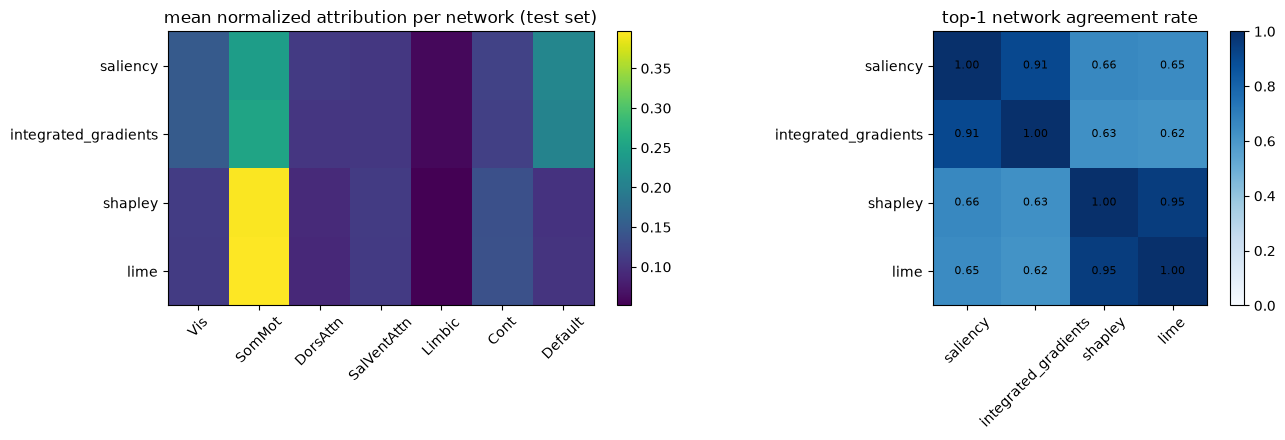

,saliency,integrated_gradients,shapley,lime
Vis,0.149,0.151,0.112,0.111
SomMot,0.244,0.253,0.395,0.397
DorsAttn,0.110,0.106,0.092,0.091
SalVentAttn,0.108,0.108,0.112,0.110
Limbic,0.059,0.059,0.052,0.051
Cont,0.120,0.117,0.135,0.137
Default,0.210,0.206,0.102,0.103


In [7]:
mean_attribution = pd.DataFrame(
    {method: [attribution_df[f"{method}__{net}"].mean() for net in NETWORK_NAMES] for method in METHODS},
    index=NETWORK_NAMES,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im = axes[0].imshow(mean_attribution.T.values, cmap="viridis", aspect="auto")
axes[0].set_xticks(range(len(NETWORK_NAMES)))
axes[0].set_xticklabels(NETWORK_NAMES, rotation=45)
axes[0].set_yticks(range(len(METHODS)))
axes[0].set_yticklabels(METHODS)
axes[0].set_title("mean normalized attribution per network (test set)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(agreement.values.astype(float), cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(len(METHODS)))
axes[1].set_xticklabels(METHODS, rotation=45)
axes[1].set_yticks(range(len(METHODS)))
axes[1].set_yticklabels(METHODS)
axes[1].set_title("top-1 network agreement rate")
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        axes[1].text(j, i, f"{agreement.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im2, ax=axes[1], fraction=0.046)

fig.tight_layout()
plt.show()

mean_attribution.round(3)


## 4. End-to-end example: decoded state → RSN → templated query

This is the piece that plugs into the RAG step: a decoded state plus its top-attributed RSN becomes a text query against the `01_pdf_ingestion` retrieval index.

In [8]:
example = per_window_df.iloc[0]
example_attr = attribution_df.iloc[0]

print(f"Decoded state:")
print(f"  subject={example['subject_id']} run={example['run']} target_volume={example['target_volume']}")
print(f"  predicted condition: {example['condition']} (confidence={example['confidence']:.2f})")
print(f"  true condition:      {example['true_condition']}")
print()
print("Top RSN by method:")
for method in METHODS:
    top_net = example_attr[f"top1__{method}"]
    score = example_attr[f"{method}__{top_net}"]
    print(f"  {method:22s} -> {top_net:12s} ({score:.2f})")

consensus_top_net = example_attr[[f"top1__{m}" for m in METHODS]].mode()[0]

query_text = (
    f"Decoded condition: {example['condition']} (confidence {example['confidence']:.0%}). "
    f"Primary contributing resting-state network: {consensus_top_net}. "
    f"MOTOR task, subject {example['subject_id']}, run {example['run']}."
)
print()
print("Templated query for RAG retrieval:")
print(" ", query_text)


Decoded state:
  subject=101309 run=LR target_volume=31
  predicted condition: right_hand (confidence=0.53)
  true condition:      right_hand

Top RSN by method:
  saliency               -> SomMot       (0.25)
  integrated_gradients   -> SomMot       (0.28)
  shapley                -> SomMot       (0.44)
  lime                   -> SomMot       (0.44)

Templated query for RAG retrieval:
  Decoded condition: right_hand (confidence 53%). Primary contributing resting-state network: SomMot. MOTOR task, subject 101309, run LR.


## Summary

- Per-window predictions and per-window RSN attribution (4 methods x 7 networks) are now saved to `results/motor_v1_per_window_predictions.csv` and `results/rsn_attribution_per_window.csv` — everything needed to build a decoded-state-to-text query for any timepoint without re-running the model.
- **The four methods split into two clusters, not one consensus.** Saliency and Integrated Gradients (both gradient-based) agree strongly with each other (90.6% top-1 network agreement, 0.96 mean rank correlation); Shapley and LIME (both perturbation-based) likewise agree strongly with each other (94.9%, 0.94). *Across* the two families, agreement drops to ~65% top-1 / ~0.39 rank correlation.
- The disagreement has a specific, interpretable shape: gradient-based methods spread meaningfully more attribution onto the **Default** network (~21%) than perturbation-based methods do (~10%), while perturbation-based methods concentrate more heavily on **SomMot** (~40% vs ~25%). For a MOTOR hand/foot/tongue decoding task, SomMot dominance is the neuroanatomically expected result — the perturbation-based methods' answer is the more literature-plausible one here, while the gradient-based methods' extra Default-network mass is either a genuine finding or a known gradient-method artifact (e.g. local gradient magnitude reflecting the loss landscape's curvature near baseline rather than true causal relevance) worth investigating before trusting it in a downstream RAG query.
- All four methods do agree on the top network for the single example walked through above (SomMot, matching the true right_hand label) — but that agreement should not be over-generalized from one example; see the aggregate tables above.
- Gradient-based (Saliency, IG) and perturbation-based (Shapley, LIME) are two genuinely different mechanisms pooled to the same 7-network output for comparability — see [docs/interpretability-methods-notes.md](../docs/interpretability-methods-notes.md) for the full rationale, this gradient-vs-perturbation discrepancy as a named open question, and a survey of methods not implemented here (including Been Kim's concept-based interpretability line).
